# List

cons：双参数过程，用于创建List（链表）<br>
car：first<br>
cdr：rest<br>
nil：empty（但是本文使用`()`）

In [6]:
(cons 2 ())

(2)

In [7]:
(
 define x (cons 1 (cons 2 ()))
)

In [8]:
x

(1 2)

In [9]:
(car x)

1

In [10]:
(cdr x)

(2)

In [13]:
(define y (cons (cons 4 (cons 3 (cons 2 ()))) x))

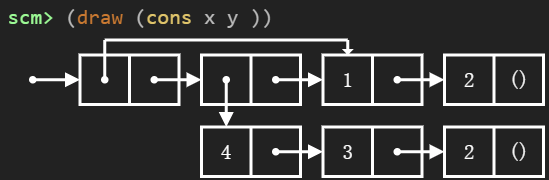

In [14]:
(cons x y)

((1 2) (4 3 2) 1 2)

x是1->2的List，y是first是4->3->2，rest是x的List

In [16]:
(cons x(cons x ()))

((1 2) (1 2))

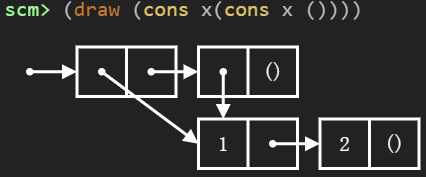

In [18]:
(null? ()) ;判断是否空

True

# 符号编程

被引用的表达式本身就是值，而不是需要求值的对象

In [25]:
(define awa 421)
'awa

awa

In [32]:
(quote pawaq);等价于 'pawaq

pawaq

可用于组合各种元素，形成列表

In [27]:
'(awa b c)

(awa b c)

**注意！这不是字符串**

In [35]:
(define x '(a b c))

In [36]:
(car x)

a

In [37]:
(cdr x)

(b c)

In [40]:
(cons 'a (cons 'b ()))

(a b)

In [43]:
(list 1 'a)
;(list 1 a) 就会报错

(1 a)

In [48]:
(car(car (cdr '(1 (2 3) 4))))

2

# 内置的List处理过程

`(append s t ...)`：将传入的列表合并为一个列表<br>
`(map f s)`：对列表s中每个元素调用过程f<br>
`(filter f s)`：创建一个包含对f为真值的s的元素的列表<br>
`(apply f s)`：将整个s作为参数传给f

In [1]:
(define s (cons 1 (cons 2 ())))

In [5]:
(define s4 (append s s s s))

In [6]:
s4

(1 2 1 2 1 2 1 2)

In [7]:
(map (lambda (x) (+ 2 x) ) s4)

(3 4 3 4 3 4 3 4)

In [11]:
(filter even? s) ;解释器问题

In [16]:
(apply + '(1 2 3 4)) ;sum

10

In [17]:
(apply / s4)

1/16

# 示例：偶数和子集

In [11]:
(define (even-subsets s)
  (if (null? s)
      '()
      (append
        (even-subsets (cdr s))
        (map (lambda (t) (cons (car s) t))
             (if (even? (car s))
                 (even-subsets (cdr s))
                 (odd-subsets (cdr s))))
        (if (even? (car s))
            (list (list (car s)))
            '()))
      )
)
(define (odd-subsets s)
  (if (null? s)
      '()
      (append
        (odd-subsets (cdr s))
        (map (lambda (t) (cons (car s) t))
             (if (odd? (car s))
                 (even-subsets (cdr s))
                 (odd-subsets (cdr s))))
        (if (odd? (car s))
            (list (list (car s)))
            '()))))

In [12]:
(even-subsets '(3 4 5 7))

((5 7) (4 5 7) (4) (3 7) (3 5) (3 4 7) (3 4 5))

In [13]:
(odd-subsets '(4 5 7))

((7) (5) (4 7) (4 5))